In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from mad.utils.ballistic_tables import load_ballistic_table, BALLISTIC_FIELD_NAMES
from mad.configs import EARTH_SETTINGS
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
table_name = "rod_of_god"
ballistic_values = load_ballistic_table(table_name)
df = pd.DataFrame({k:ballistic_values.table[:, i] for i, k in enumerate(BALLISTIC_FIELD_NAMES)})

In [4]:

df["range_km"] = df["range_rad"] * EARTH_SETTINGS["radius"] / 1000
df["altitude_km"] = df["altitude_m"] / 1000
df["gamma_deg"] = df["gamma_rad"] * 180 / np.pi


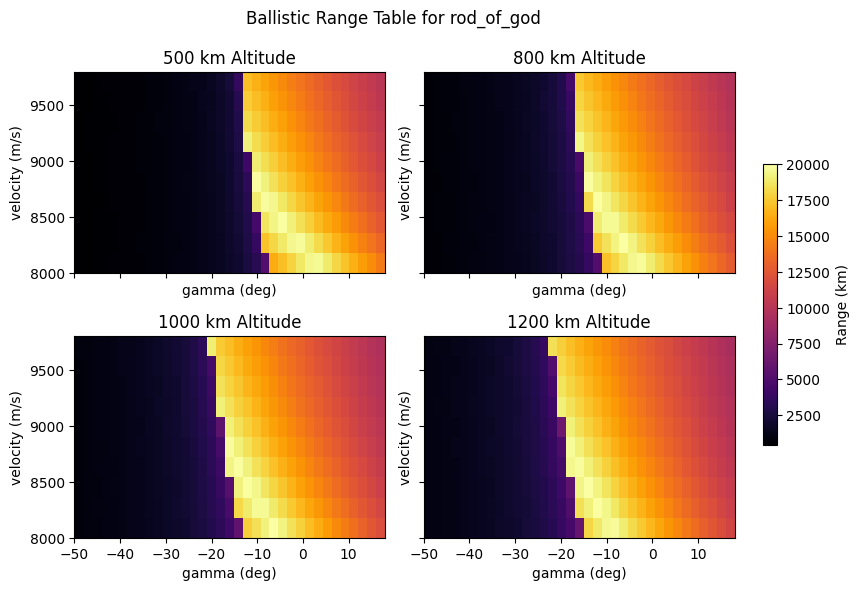

In [5]:
selected_altitudes = [500, 800, 1000, 1200]
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(8, 6), sharex=True, sharey=True)
ax = ax.ravel()

# Compute global vmin/vmax across all selected altitudes for a shared colorscale
dfs = [df[df["altitude_km"] == alt].pivot(index="velocity_m_s", columns="gamma_deg", values="range_km")
       for alt in selected_altitudes]
vmin = min(d.values.min() for d in dfs if not d.empty)
vmax = max(d.values.max() for d in dfs if not d.empty)

imgs = []
for i, (selected_altitude, df2) in enumerate(zip(selected_altitudes, dfs)):
    if df2.empty:
        continue
    img = ax[i].imshow(
        df2.values,
        extent=(df2.columns.min(), df2.columns.max(), df2.index.min(), df2.index.max()),
        aspect="auto",
        origin="lower",
        vmin=vmin,
        vmax=vmax,
        cmap="inferno",
    )
    imgs.append(img)
    ax[i].set_xlabel("gamma (deg)")
    ax[i].set_ylabel("velocity (m/s)")
    ax[i].set_title(f"{selected_altitude} km Altitude")

fig.suptitle(f"Ballistic Range Table for {table_name}")
fig.tight_layout(pad=1.2)
cbar = fig.colorbar(imgs[0], ax=ax, fraction=0.02, pad=0.04, label="Range (km)")

In [ ]:
df[(20 < df["range_km"]) & (df["range_km"] < 30)]